注意
* submission中，对于每个trip，我们给出4个预估的下一个city_id
* ground_truth中，主要是对test_set中的每个trip给出下一个正确的city_id
* 评估指标是看这4个city_id是否有正确的

# Train Set Data Analysis
## Multi-Destination Trips Dataset Exploration

In [4]:
import sys
from pathlib import Path

_repo = Path.cwd()
if not (_repo / "src").is_dir():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [ ]:
# Load training data
from src.utils.paths import data_dir

train_set = pd.read_csv(data_dir() / "train_set.csv")
print(f"Data shape: {train_set.shape}")
print(f"Total records: {train_set.shape[0]:,}")
print(f"Number of features: {train_set.shape[1]}")

Data shape: (1166835, 9)
Total records: 1,166,835
Number of features: 9


## 2. Basic Information

In [6]:
# Display first few rows
train_set.head(10)

,user_id,checkin,checkout,city_id,device_class,affiliate_id,booker_country,hotel_country,utrip_id
0,1000027,2016-08-13,2016-08-14,8183,desktop,7168,Elbonia,Gondal,1000027_1
1,1000027,2016-08-14,2016-08-16,15626,desktop,7168,Elbonia,Gondal,1000027_1
2,1000027,2016-08-16,2016-08-18,60902,desktop,7168,Elbonia,Gondal,1000027_1
3,1000027,2016-08-18,2016-08-21,30628,desktop,253,Elbonia,Gondal,1000027_1
4,1000033,2016-04-09,2016-04-11,38677,mobile,359,Gondal,Cobra Island,1000033_1
5,1000033,2016-04-11,2016-04-12,52089,desktop,384,Gondal,Cobra Island,1000033_1
6,1000033,2016-04-12,2016-04-14,21328,desktop,384,Gondal,Cobra Island,1000033_1
7,1000033,2016-04-14,2016-04-16,27485,desktop,384,Gondal,Cobra Island,1000033_1
8,1000033,2016-04-16,2016-04-19,38677,desktop,384,Gondal,Cobra Island,1000033_1
9,1000045,2016-06-18,2016-06-20,64876,desktop,2790,The Devilfire Empire,Fook Island,1000045_1


In [7]:
# Data types and info
train_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166835 entries, 0 to 1166834
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   user_id         1166835 non-null  int64 
 1   checkin         1166835 non-null  object
 2   checkout        1166835 non-null  object
 3   city_id         1166835 non-null  int64 
 4   device_class    1166835 non-null  object
 5   affiliate_id    1166835 non-null  int64 
 6   booker_country  1166835 non-null  object
 7   hotel_country   1166835 non-null  object
 8   utrip_id        1166835 non-null  object
dtypes: int64(3), object(6)
memory usage: 80.1+ MB


In [8]:
# Check for missing values
missing_values = train_set.isnull().sum()
missing_percent = (train_set.isnull().sum() / len(train_set)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])
if missing_df['Missing Count'].sum() == 0:
    print("No missing values found")

Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No missing values found


## 3. Statistical Summary

In [9]:
# Unique values for each column
for col in train_set.columns:
    unique_count = train_set[col].nunique()
    print(f"{col:20s}: {unique_count:8,} unique values")

user_id             :  200,153 unique values
checkin             :      425 unique values
checkout            :      425 unique values
city_id             :   39,901 unique values
device_class        :        3 unique values
affiliate_id        :    3,254 unique values
booker_country      :        5 unique values
hotel_country       :      195 unique values
utrip_id            :  217,686 unique values


## 4. User Analysis

In [10]:
# User statistics
n_users = train_set['user_id'].nunique()
n_trips = train_set['utrip_id'].nunique()

print(f"Number of unique users: {n_users:,}")
print(f"Number of unique trips (utrip_id): {n_trips:,}")

bookings_per_user = train_set.groupby('user_id').size()
print(f"\nAverage bookings per user: {bookings_per_user.mean():.2f}")
print(f"Max bookings per user: {bookings_per_user.max()}")
print(f"Min bookings per user: {bookings_per_user.min()}")

Number of unique users: 200,153
Number of unique trips (utrip_id): 217,686

Average bookings per user: 5.83
Max bookings per user: 172
Min bookings per user: 1


## 5. Trip Pattern Analysis

In [11]:
# Cities per trip
cities_per_trip = train_set.groupby('utrip_id').size()

print(f"Average cities per trip: {cities_per_trip.mean():.2f}")
print(f"Max cities per trip: {cities_per_trip.max()}")
print(f"Min cities per trip: {cities_per_trip.min()}")
print(f"\nDistribution of cities per trip:")
print(cities_per_trip.value_counts().sort_index())

Average cities per trip: 5.36
Max cities per trip: 48
Min cities per trip: 1

Distribution of cities per trip:
1       113
2       174
3       593
4     98356
5     49854
6     27398
7     16101
8      9486
9      5774
10     3573
11     2236
12     1431
13      903
14      593
15      365
16      221
17      138
18       93
19       64
20       66
21       35
22       31
23       22
24       13
25       14
26        7
27        3
28        5
29        1
30        3
31        2
32        1
33        4
34        1
35        1
36        3
39        3
41        2
44        1
45        1
48        1
Name: count, dtype: int64


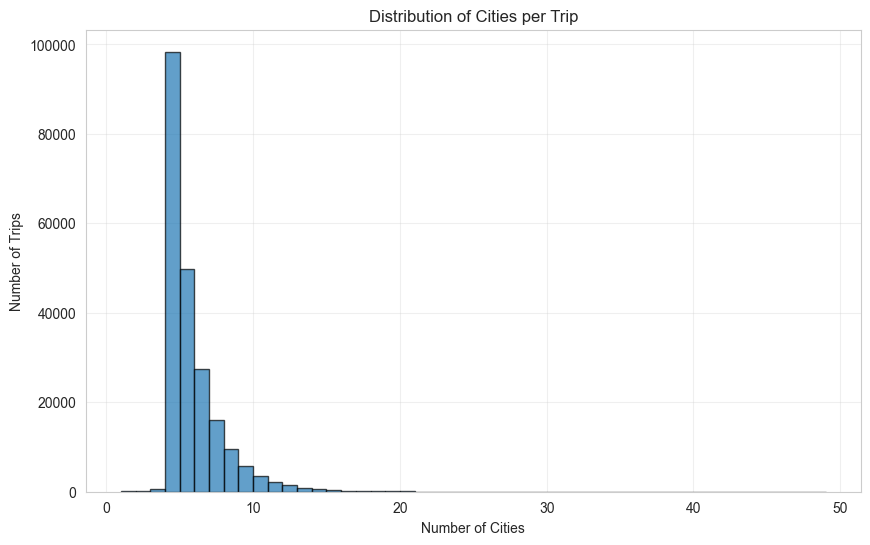

In [12]:
# Visualize cities per trip distribution
plt.figure(figsize=(10, 6))
plt.hist(cities_per_trip, bins=range(1, cities_per_trip.max()+2), edgecolor='black', alpha=0.7)
plt.xlabel('Number of Cities')
plt.ylabel('Number of Trips')
plt.title('Distribution of Cities per Trip')
plt.grid(True, alpha=0.3)
plt.show()

## 6. City Analysis

In [13]:
# City statistics
n_cities = train_set['city_id'].nunique()
print(f"Number of unique cities: {n_cities:,}")

print(f"\nTop 20 most popular cities:")
top_cities = train_set['city_id'].value_counts().head(20)
print(top_cities)

Number of unique cities: 39,901

Top 20 most popular cities:
city_id
47499    11242
23921    10511
36063     9559
17013     9011
29319     8179
64876     7784
55128     7763
17127     6893
2416      6641
66648     6625
60222     6278
51259     6093
29770     6088
26235     5818
48483     5731
3763      5544
10485     5351
55763     5317
4932      5205
26436     5094
Name: count, dtype: int64


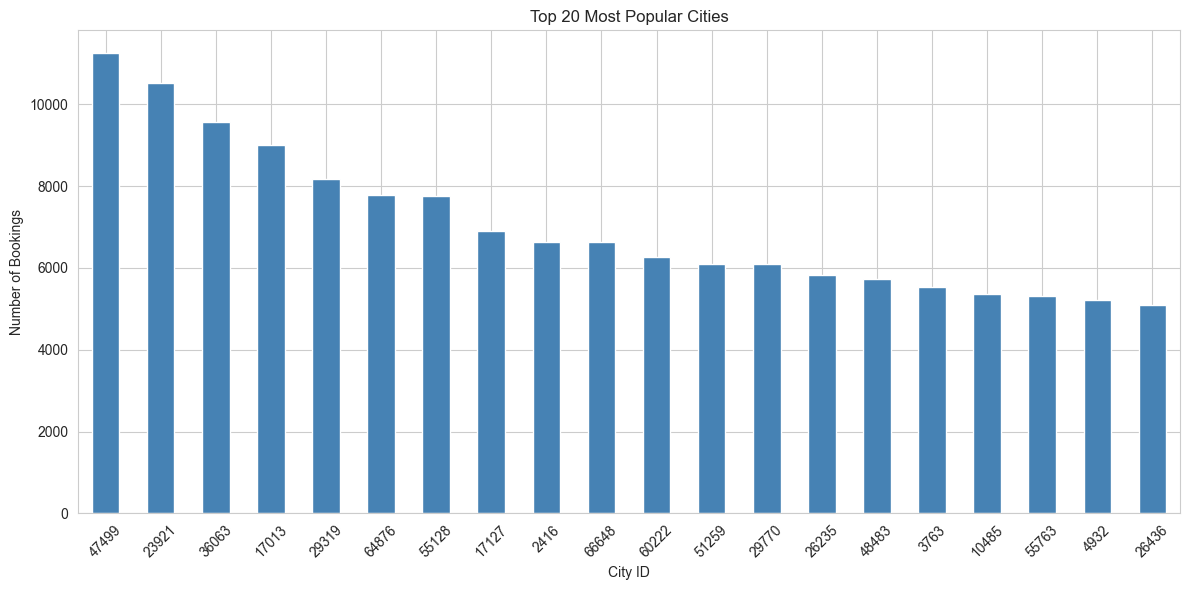

In [14]:
# Visualize top cities
plt.figure(figsize=(12, 6))
top_cities.plot(kind='bar', color='steelblue')
plt.xlabel('City ID')
plt.ylabel('Number of Bookings')
plt.title('Top 20 Most Popular Cities')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Device Type Analysis

In [15]:
# Device distribution
device_dist = train_set['device_class'].value_counts()
print("Device type distribution:")
print(device_dist)
print(f"\nDevice type percentage:")
print((device_dist / len(train_set) * 100).round(2))

Device type distribution:
device_class
desktop    753860
mobile     331856
tablet      81119
Name: count, dtype: int64

Device type percentage:
device_class
desktop    64.61
mobile     28.44
tablet      6.95
Name: count, dtype: float64


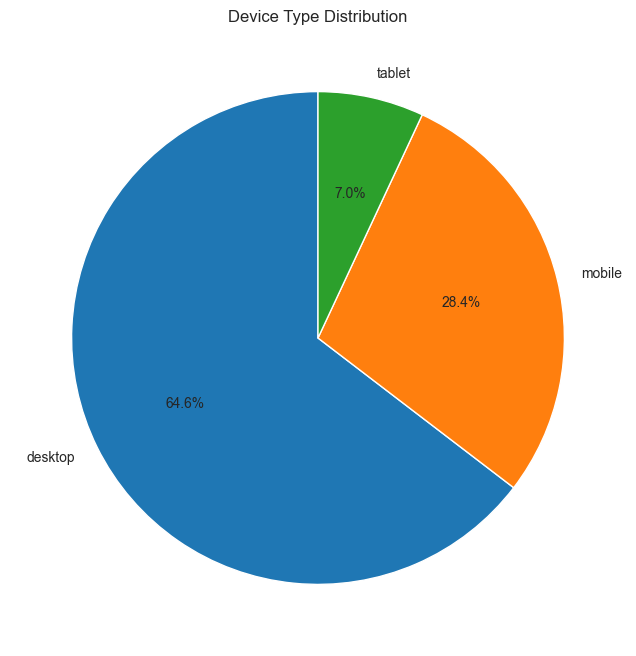

In [16]:
# Visualize device distribution
plt.figure(figsize=(8, 8))
device_dist.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.ylabel('')
plt.title('Device Type Distribution')
plt.show()

## 8. Country Analysis

In [17]:
# Country statistics
print(f"Number of booker countries: {train_set['booker_country'].nunique()}")
print(f"Number of hotel countries: {train_set['hotel_country'].nunique()}")

print(f"\nTop 10 booker countries:")
print(train_set['booker_country'].value_counts().head(10))

print(f"\nTop 10 hotel countries:")
print(train_set['hotel_country'].value_counts().head(10))

Number of booker countries: 5
Number of hotel countries: 195

Top 10 booker countries:
booker_country
Gondal                  536036
The Devilfire Empire    286244
Elbonia                 235344
Tcherkistan              80573
Bartovia                 28638
Name: count, dtype: int64

Top 10 hotel countries:
hotel_country
Cobra Island              137791
Fook Island               117717
Gondal                    104979
Glubbdubdrib               74840
Elbonia                    53965
Borginia                   45629
Kangan                     44876
Bozatta                    40599
Alvonia                    34446
Holy Britannian Empire     30040
Name: count, dtype: int64


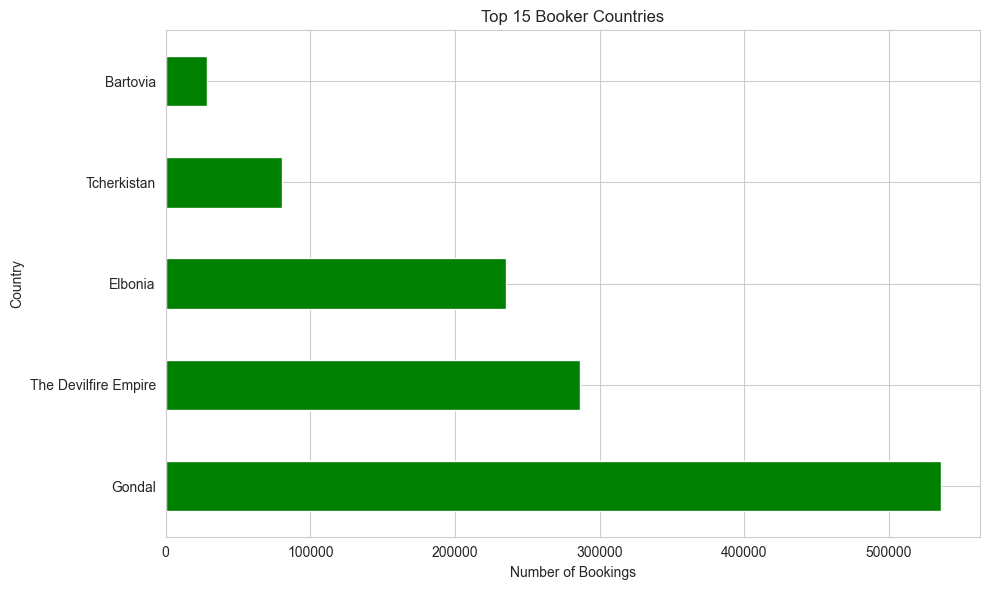

In [18]:
# Visualize booker countries
plt.figure(figsize=(10, 6))
top_booker_countries = train_set['booker_country'].value_counts().head(15)
top_booker_countries.plot(kind='barh', color='green')
plt.xlabel('Number of Bookings')
plt.ylabel('Country')
plt.title('Top 15 Booker Countries')
plt.tight_layout()
plt.show()

In [19]:
# Cross-country bookings
is_cross_country = train_set['booker_country'] != train_set['hotel_country']
cross_country_ratio = is_cross_country.mean() * 100
print(f"Cross-country booking ratio: {cross_country_ratio:.2f}%")

Cross-country booking ratio: 90.41%


## 9. Date and Duration Analysis

In [20]:
# Convert to datetime
checkin_dates = pd.to_datetime(train_set['checkin'])
checkout_dates = pd.to_datetime(train_set['checkout'])
stay_duration = (checkout_dates - checkin_dates).dt.days

print(f"Check-in date range: {checkin_dates.min()} to {checkin_dates.max()}")
print(f"Check-out date range: {checkout_dates.min()} to {checkout_dates.max()}")
print(f"\nStay duration statistics (days):")
print(stay_duration.describe())

Check-in date range: 2015-12-31 00:00:00 to 2017-02-27 00:00:00
Check-out date range: 2016-01-01 00:00:00 to 2017-02-28 00:00:00

Stay duration statistics (days):
count    1.166835e+06
mean     1.739171e+00
std      1.197427e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      3.000000e+01
dtype: float64


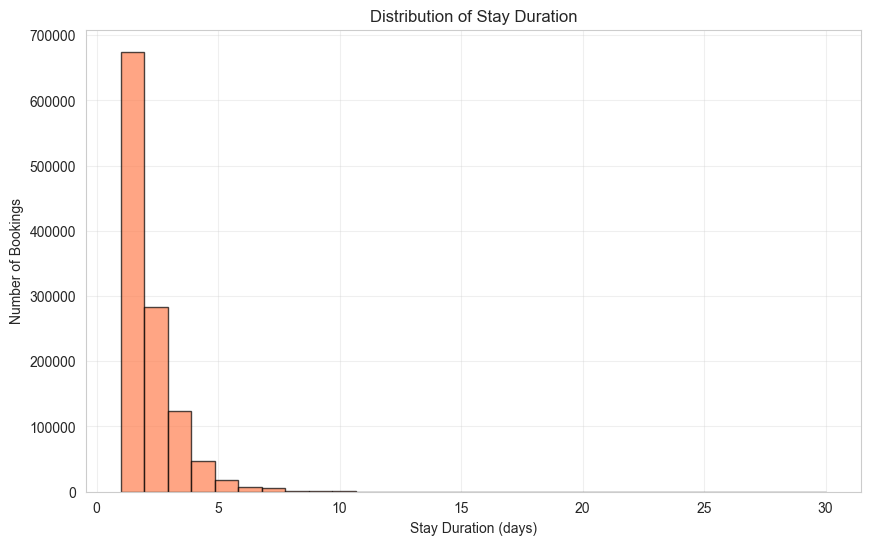

In [21]:
# Visualize stay duration
plt.figure(figsize=(10, 6))
plt.hist(stay_duration, bins=30, edgecolor='black', color='coral', alpha=0.7)
plt.xlabel('Stay Duration (days)')
plt.ylabel('Number of Bookings')
plt.title('Distribution of Stay Duration')
plt.grid(True, alpha=0.3)
plt.show()

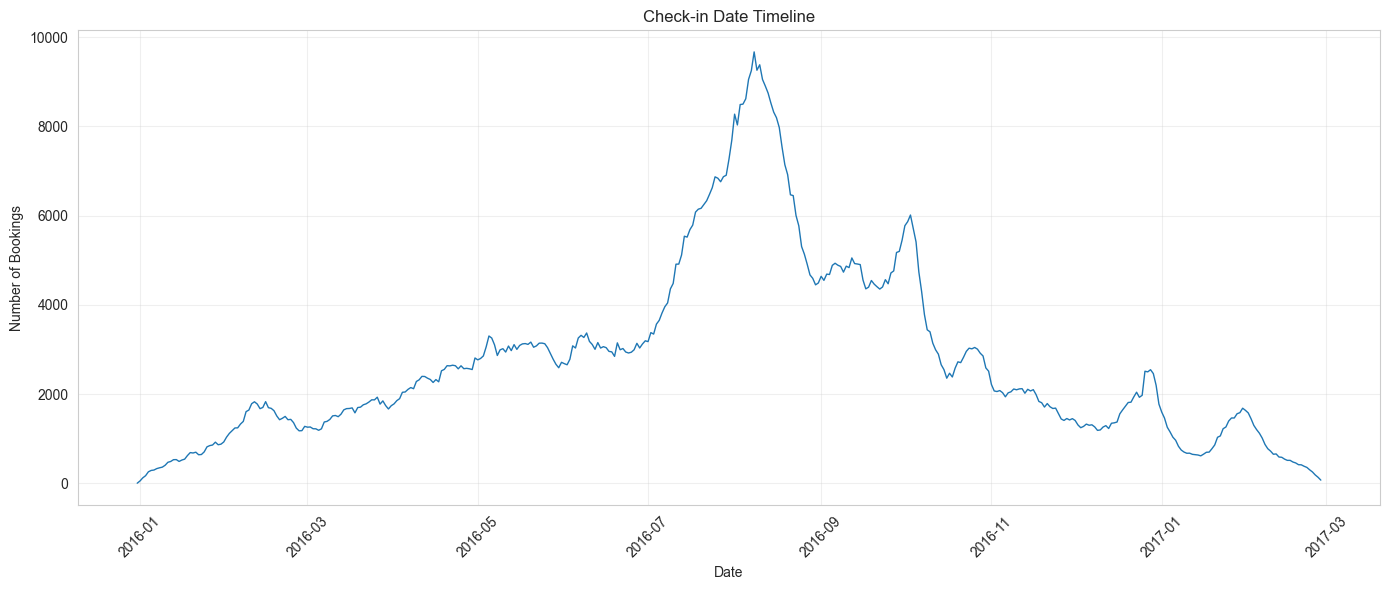

In [22]:
# Check-in timeline
checkin_counts = checkin_dates.dt.date.value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(checkin_counts.index, checkin_counts.values, linewidth=1)
plt.xlabel('Date')
plt.ylabel('Number of Bookings')
plt.title('Check-in Date Timeline')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Trip Duration Analysis

In [23]:
# Total trip duration (from first check-in to last check-out per trip)
trip_data = pd.DataFrame({
    'utrip_id': train_set['utrip_id'],
    'checkin': checkin_dates,
    'checkout': checkout_dates
})
trip_duration = trip_data.groupby('utrip_id').agg({
    'checkin': 'min',
    'checkout': 'max'
})
trip_duration['total_duration'] = (trip_duration['checkout'] - trip_duration['checkin']).dt.days

print("Total trip duration statistics (days):")
print(trip_duration['total_duration'].describe())

Total trip duration statistics (days):
count    217686.000000
mean          9.402617
std           4.827897
min           1.000000
25%           6.000000
50%           8.000000
75%          12.000000
max         318.000000
Name: total_duration, dtype: float64


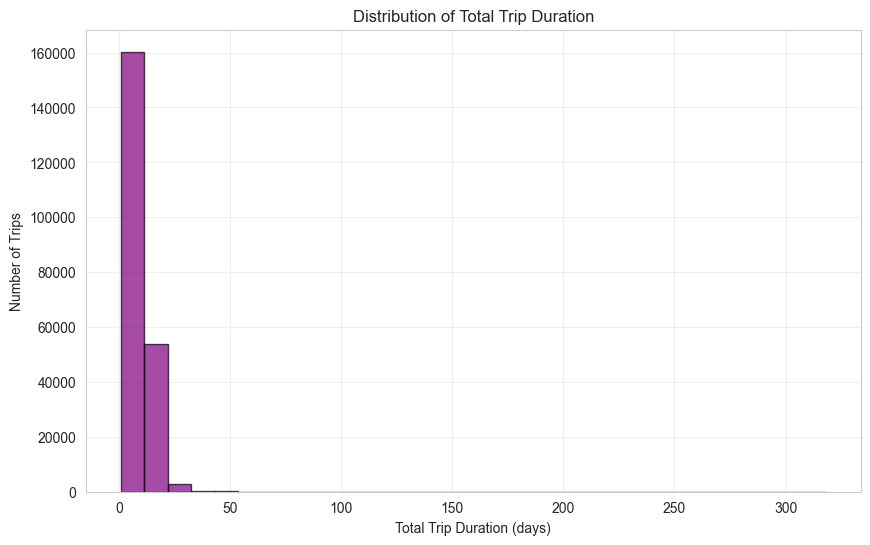

In [24]:
# Visualize trip duration
plt.figure(figsize=(10, 6))
plt.hist(trip_duration['total_duration'], bins=30, edgecolor='black', color='purple', alpha=0.7)
plt.xlabel('Total Trip Duration (days)')
plt.ylabel('Number of Trips')
plt.title('Distribution of Total Trip Duration')
plt.grid(True, alpha=0.3)
plt.show()

## 11. Affiliate ID Analysis

In [25]:
# Affiliate statistics
print(f"Number of unique affiliate IDs: {train_set['affiliate_id'].nunique()}")
print(f"\nTop 10 affiliate IDs:")
print(train_set['affiliate_id'].value_counts().head(10))

Number of unique affiliate IDs: 3254

Top 10 affiliate IDs:
affiliate_id
9924     277775
359      171385
384       88137
9452      85476
4541      41504
8436      31275
10332     27309
3631      25606
9598      24329
8132      22254
Name: count, dtype: int64


## 12. Comprehensive Visualization

FileNotFoundError: [Errno 2] No such file or directory: 'output/train_set_analysis.png'

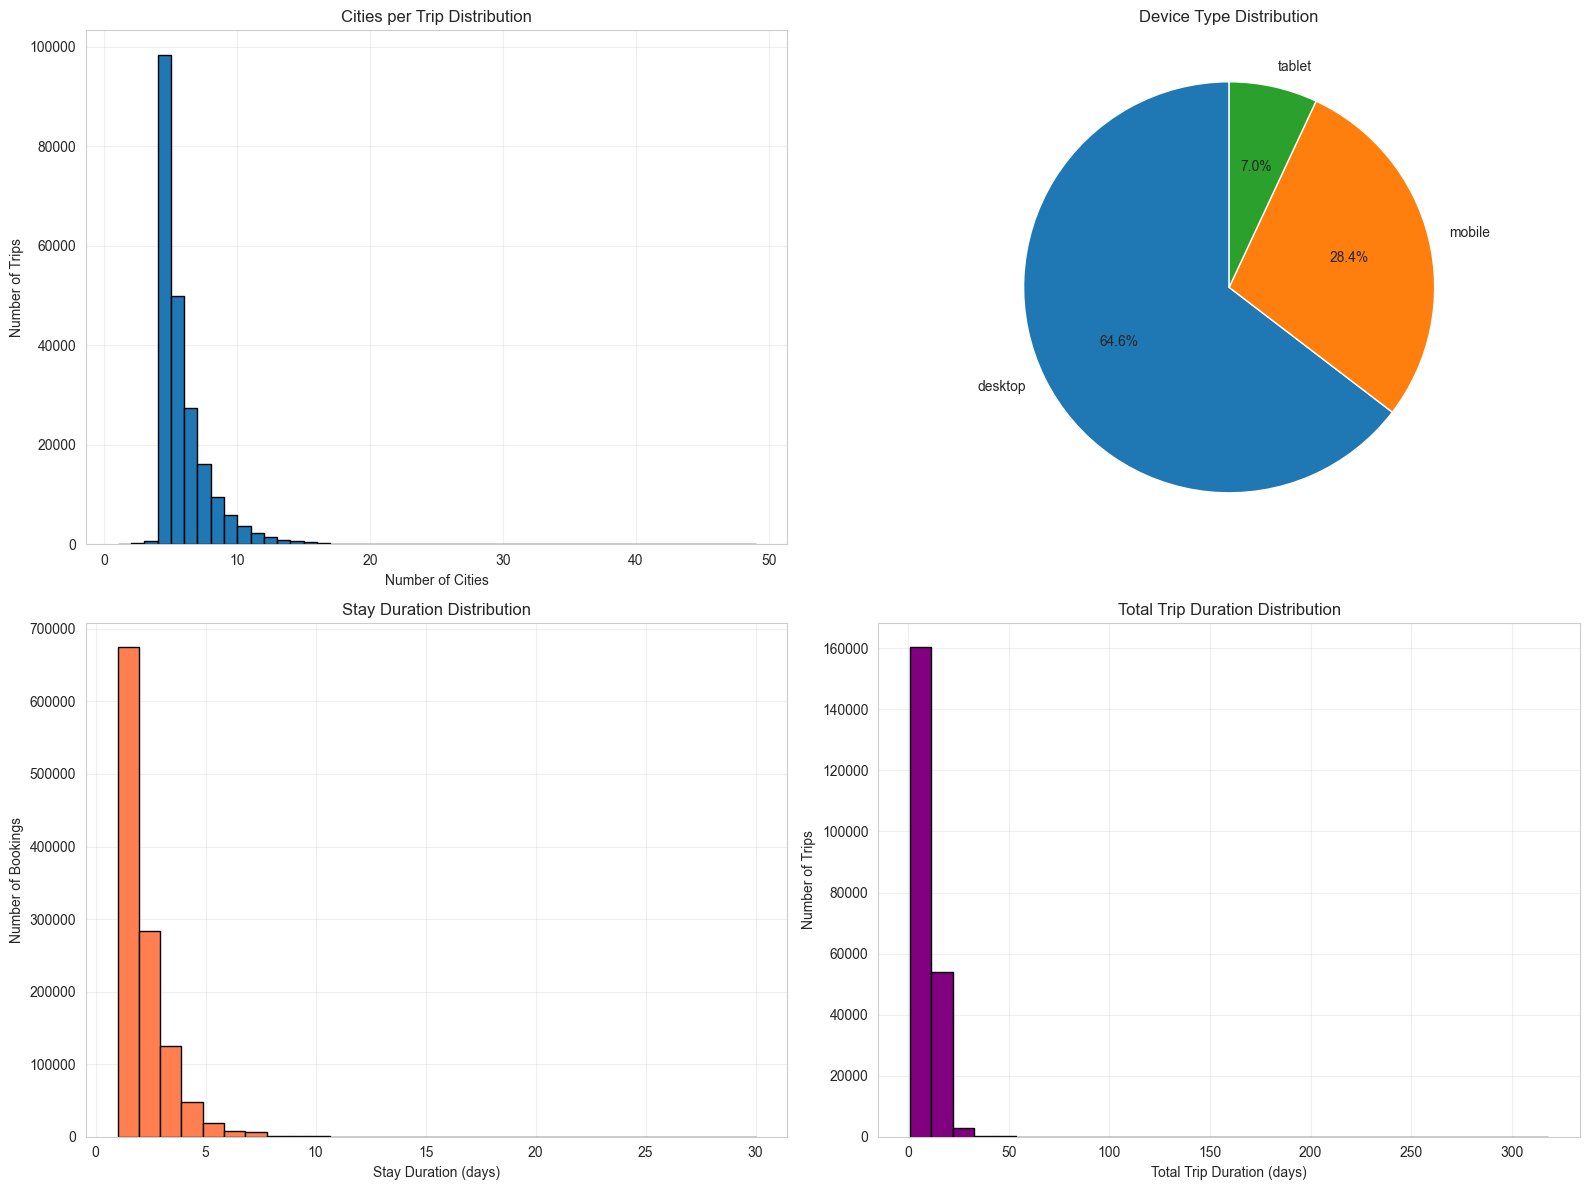

In [26]:
# Create a comprehensive dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Cities per trip
axes[0, 0].hist(cities_per_trip, bins=range(1, cities_per_trip.max()+2), edgecolor='black')
axes[0, 0].set_xlabel('Number of Cities')
axes[0, 0].set_ylabel('Number of Trips')
axes[0, 0].set_title('Cities per Trip Distribution')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Device distribution
device_dist.plot(kind='pie', ax=axes[0, 1], autopct='%1.1f%%', startangle=90)
axes[0, 1].set_ylabel('')
axes[0, 1].set_title('Device Type Distribution')

# Plot 3: Stay duration
axes[1, 0].hist(stay_duration, bins=30, edgecolor='black', color='coral')
axes[1, 0].set_xlabel('Stay Duration (days)')
axes[1, 0].set_ylabel('Number of Bookings')
axes[1, 0].set_title('Stay Duration Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Trip duration
axes[1, 1].hist(trip_duration['total_duration'], bins=30, edgecolor='black', color='purple')
axes[1, 1].set_xlabel('Total Trip Duration (days)')
axes[1, 1].set_ylabel('Number of Trips')
axes[1, 1].set_title('Total Trip Duration Distribution')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('output/train_set_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Visualization saved to: output/train_set_analysis.png")

## 13. Summary Statistics Table

In [ ]:
# Create summary table
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique Users',
        'Unique Trips',
        'Unique Cities',
        'Unique Booker Countries',
        'Unique Hotel Countries',
        'Average Cities per Trip',
        'Average Stay Duration (days)',
        'Average Trip Duration (days)',
        'Cross-country Booking Ratio (%)'
    ],
    'Value': [
        f"{len(train_set):,}",
        f"{train_set['user_id'].nunique():,}",
        f"{train_set['utrip_id'].nunique():,}",
        f"{train_set['city_id'].nunique():,}",
        f"{train_set['booker_country'].nunique():,}",
        f"{train_set['hotel_country'].nunique():,}",
        f"{cities_per_trip.mean():.2f}",
        f"{stay_duration.mean():.2f}",
        f"{trip_duration['total_duration'].mean():.2f}",
        f"{cross_country_ratio:.2f}"
    ]
})

print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(summary_stats.to_string(index=False))
print("="*60)


DATASET SUMMARY
                         Metric     Value
                  Total Records 1,166,835
                   Unique Users   200,153
                   Unique Trips   217,686
                  Unique Cities    39,901
        Unique Booker Countries         5
         Unique Hotel Countries       195
        Average Cities per Trip      5.36
   Average Stay Duration (days)      1.74
   Average Trip Duration (days)      9.40
Cross-country Booking Ratio (%)     90.41
